# Fish Species Classification for Aquaculture Using Convolutional Neural Networks and Transfer Learning

## Machine Learning Project – Phase 2

**Student Name:** Harshavardhan Babu Bokka  
**Matriculation Number:** 74336308  

### Project Description

This project develops a Convolutional Neural Network (CNN)-based image classification system to automatically identify fish species using the **A Large Scale Fish Dataset** from Kaggle.

The objectives of this project are:

- Explore and preprocess the fish image dataset.
- Develop a custom CNN model.
- Compare the custom CNN with transfer learning models.
- Evaluate the models using standard performance metrics.
- Identify the best-performing model for fish species classification.

---

**Dataset**

A Large Scale Fish Dataset

https://www.kaggle.com/datasets/crowww/a-large-scale-fish-dataset

In [1]:
# ============================================================
# Import Libraries
# ============================================================

import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (Conv2D,
                                     MaxPooling2D,
                                     Dense,
                                     Flatten,
                                     Dropout,
                                     BatchNormalization)

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (EarlyStopping,
                                        ReduceLROnPlateau,
                                        ModelCheckpoint)

from tensorflow.keras.applications import MobileNetV2

print("="*60)
print("Fish Species Classification Project")
print("="*60)
print("TensorFlow Version :", tf.__version__)
print("NumPy Version      :", np.__version__)
print("Pandas Version     :", pd.__version__)
print("="*60)

Fish Species Classification Project
TensorFlow Version : 2.20.0
NumPy Version      : 2.0.2
Pandas Version     : 2.3.3


In [2]:
# ============================================================
# Project Configuration
# ============================================================

# Dataset Path
DATASET_PATH = "/kaggle/input/datasets/crowww/a-large-scale-fish-dataset/Fish_Dataset/Fish_Dataset"

# Image Settings
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
RANDOM_SEED = 42

# Set random seed
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("="*60)
print("Project Configuration")
print("="*60)
print("Dataset Path :", DATASET_PATH)
print("Image Size   :", IMAGE_SIZE)
print("Batch Size   :", BATCH_SIZE)
print("Epochs       :", EPOCHS)
print("Random Seed  :", RANDOM_SEED)
print("="*60)

Project Configuration
Dataset Path : /kaggle/input/datasets/crowww/a-large-scale-fish-dataset/Fish_Dataset/Fish_Dataset
Image Size   : (224, 224)
Batch Size   : 32
Epochs       : 20
Random Seed  : 42


In [3]:
# ============================================================
# Dataset Information
# ============================================================

fish_classes = sorted([
    folder for folder in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, folder))
])

image_count = 0

for fish in fish_classes:
    fish_folder = os.path.join(DATASET_PATH, fish, fish)
    image_count += len([
        img for img in os.listdir(fish_folder)
        if img.lower().endswith((".png", ".jpg", ".jpeg"))
    ])

print("="*60)
print("Dataset Information")
print("="*60)
print("Number of Classes :", len(fish_classes))
print("Total Images      :", image_count)
print("\nFish Species:\n")

for fish in fish_classes:
    print("-", fish)

print("="*60)

Dataset Information
Number of Classes : 9
Total Images      : 9000

Fish Species:

- Black Sea Sprat
- Gilt-Head Bream
- Hourse Mackerel
- Red Mullet
- Red Sea Bream
- Sea Bass
- Shrimp
- Striped Red Mullet
- Trout


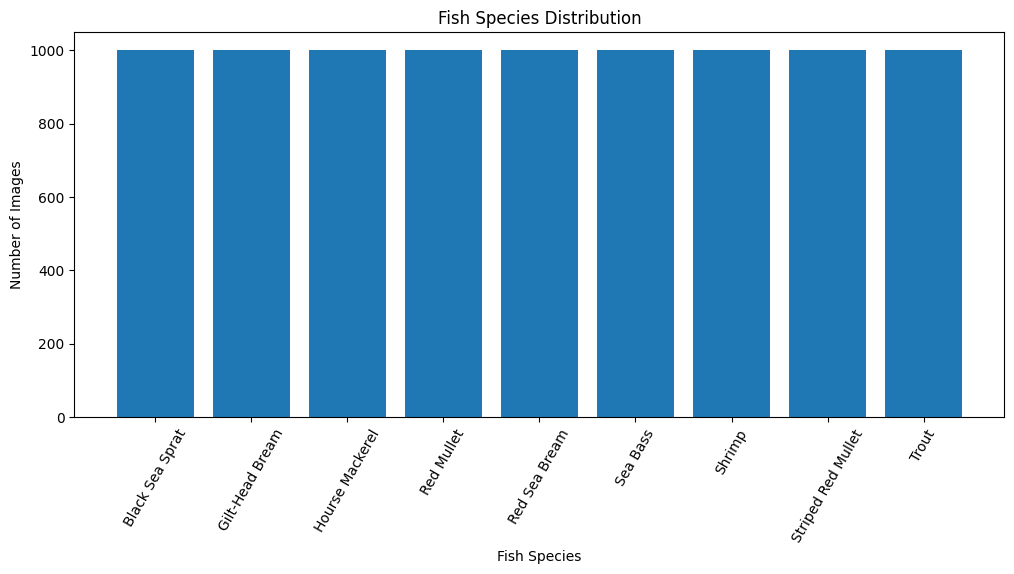

In [4]:
# ============================================================
# Dataset Visualization
# ============================================================

species_count = {}

for fish in fish_classes:
    folder = os.path.join(DATASET_PATH, fish, fish)
    species_count[fish] = len([
        img for img in os.listdir(folder)
        if img.lower().endswith((".jpg", ".png", ".jpeg"))
    ])

plt.figure(figsize=(12,5))
plt.bar(species_count.keys(), species_count.values())

plt.title("Fish Species Distribution")
plt.xlabel("Fish Species")
plt.ylabel("Number of Images")

plt.xticks(rotation=60)

plt.show()

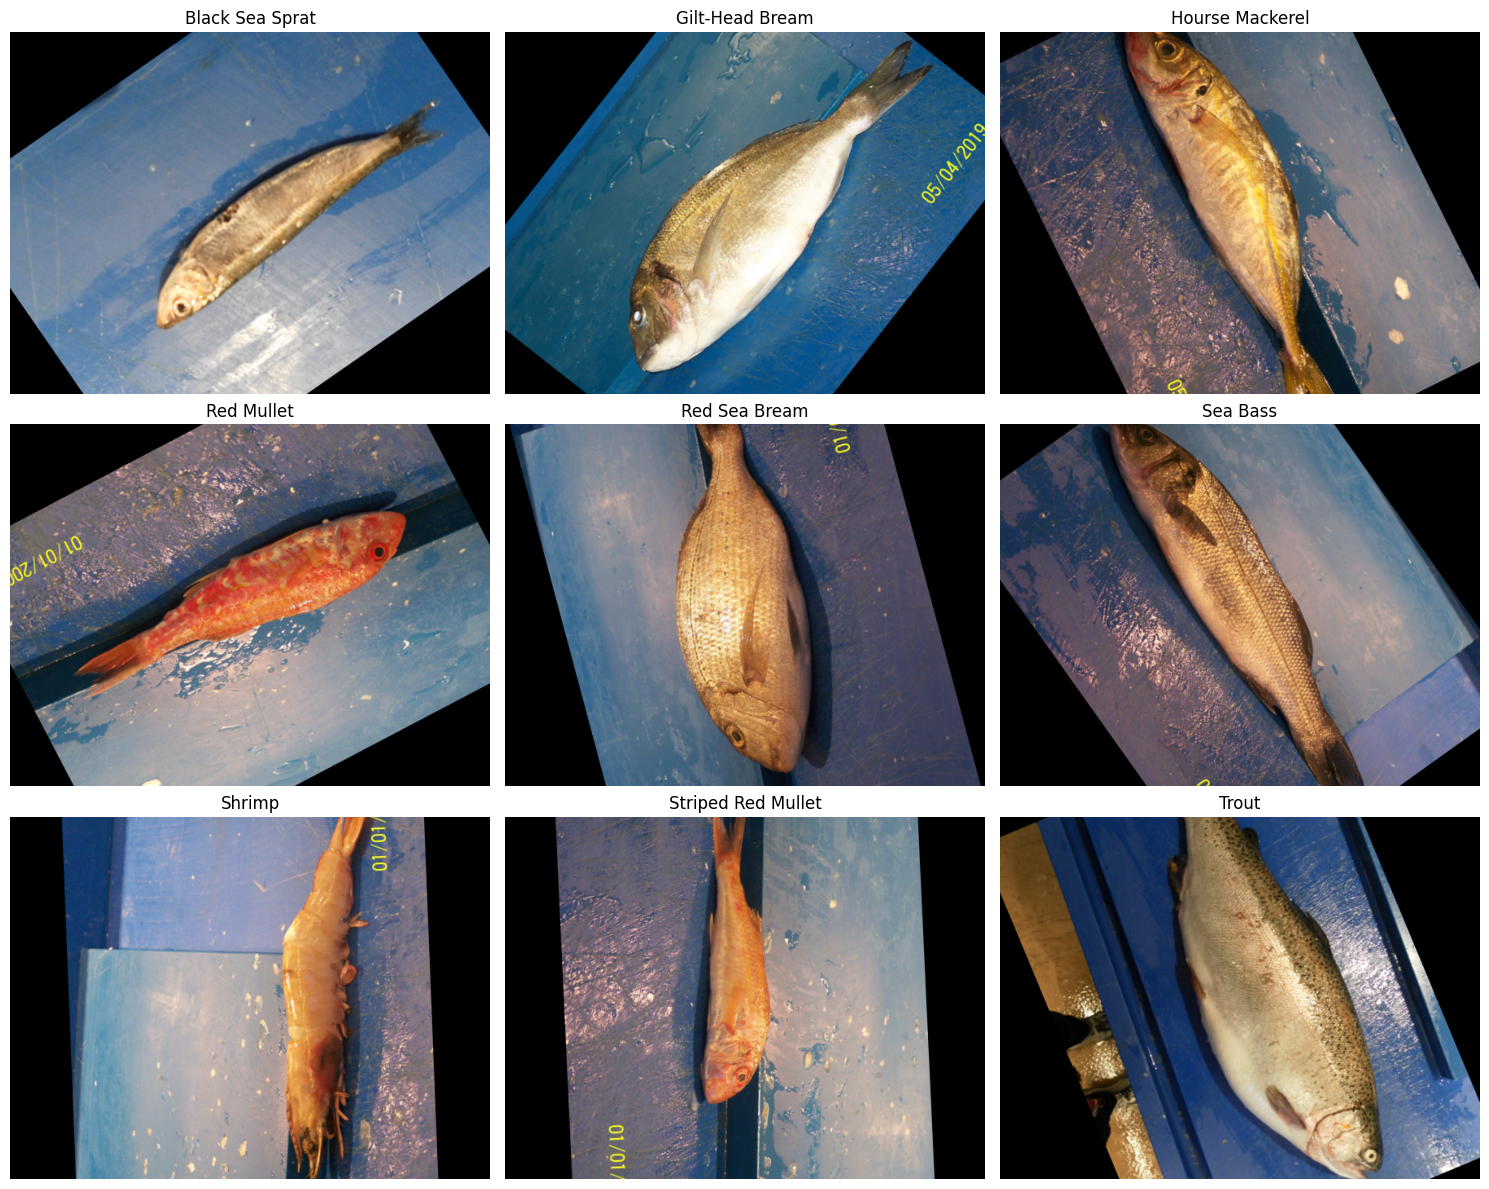

In [5]:
# ============================================================
# Display Sample Images
# ============================================================

plt.figure(figsize=(15,12))

for i, fish in enumerate(fish_classes):

    folder = os.path.join(DATASET_PATH, fish, fish)

    image_name = sorted([
        img for img in os.listdir(folder)
        if img.lower().endswith((".jpg",".png",".jpeg"))
    ])[0]

    image_path = os.path.join(folder, image_name)

    image = Image.open(image_path)

    plt.subplot(3,3,i+1)
    plt.imshow(image)
    plt.title(fish)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# Create Image DataFrame
# ============================================================

image_paths = []
labels = []

for fish in fish_classes:

    folder = os.path.join(DATASET_PATH, fish, fish)

    for image in os.listdir(folder):

        if image.lower().endswith((".jpg", ".jpeg", ".png")):

            image_paths.append(os.path.join(folder, image))
            labels.append(fish)

fish_df = pd.DataFrame({
    "filepath": image_paths,
    "label": labels
})

print("="*60)
print("Dataset DataFrame Created Successfully")
print("="*60)
print("Total Images :", len(fish_df))
print()
print(fish_df.head())

Dataset DataFrame Created Successfully
Total Images : 9000

                                            filepath            label
0  /kaggle/input/datasets/crowww/a-large-scale-fi...  Black Sea Sprat
1  /kaggle/input/datasets/crowww/a-large-scale-fi...  Black Sea Sprat
2  /kaggle/input/datasets/crowww/a-large-scale-fi...  Black Sea Sprat
3  /kaggle/input/datasets/crowww/a-large-scale-fi...  Black Sea Sprat
4  /kaggle/input/datasets/crowww/a-large-scale-fi...  Black Sea Sprat


In [7]:
# ============================================================
# Train / Validation / Test Split
# ============================================================

train_df, temp_df = train_test_split(
    fish_df,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=fish_df["label"]
)

valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=temp_df["label"]
)

print("="*60)
print("Dataset Split")
print("="*60)
print("Training Images   :", len(train_df))
print("Validation Images :", len(valid_df))
print("Testing Images    :", len(test_df))

Dataset Split
Training Images   : 6300
Validation Images : 1350
Testing Images    : 1350


In [8]:
# ============================================================
# Image Data Augmentation
# ============================================================

train_generator = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.20,
    horizontal_flip=True,
    width_shift_range=0.20,
    height_shift_range=0.20
)

validation_generator = ImageDataGenerator(
    rescale=1./255
)

test_generator = ImageDataGenerator(
    rescale=1./255
)

print("="*60)
print("Image Generators Created Successfully")
print("="*60)

Image Generators Created Successfully


In [9]:
# ============================================================
# Create Data Generators
# ============================================================

train_data = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="label",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

validation_data = validation_generator.flow_from_dataframe(
    dataframe=valid_df,
    x_col="filepath",
    y_col="label",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_data = test_generator.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="label",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 6300 validated image filenames belonging to 9 classes.
Found 1350 validated image filenames belonging to 9 classes.
Found 1350 validated image filenames belonging to 9 classes.


In [10]:
# ============================================================
# Custom CNN Model
# ============================================================

custom_cnn = Sequential([

    # Block 1
    Conv2D(32, (3,3), activation="relu",
           padding="same",
           input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Block 2
    Conv2D(64, (3,3), activation="relu",
           padding="same"),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Block 3
    Conv2D(128, (3,3), activation="relu",
           padding="same"),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Block 4
    Conv2D(256, (3,3), activation="relu",
           padding="same"),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(512, activation="relu"),
    Dropout(0.5),

    Dense(9, activation="softmax")

])

print("Custom CNN Created Successfully")

I0000 00:00:1783104532.968255      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783104532.974471      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Custom CNN Created Successfully


In [11]:
# ============================================================
# Compile Custom CNN
# ============================================================

custom_cnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model Compiled Successfully")

Model Compiled Successfully


In [12]:
# ============================================================
# Model Summary
# ============================================================

custom_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         4,617 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,085,577 (99.51 MB)

 Trainable params: 26,084,617 (99.50 MB)

 Non-trainable params: 960 (3.75 KB)

In [13]:
# ============================================================
# Training Callbacks
# ============================================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    verbose=1,
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    "best_custom_cnn.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

print("Callbacks Created Successfully")

Callbacks Created Successfully


In [14]:
# ============================================================
# Train Custom CNN
# ============================================================

history_cnn = custom_cnn.fit(

    train_data,

    validation_data=validation_data,

    epochs=EPOCHS,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]

)

print("Training Finished!")

Epoch 1/20
  2/197 ━━━━━━━━━━━━━━━━━━━━ 18s 94ms/step - accuracy: 0.1250 - loss: 16.2738

I0000 00:00:1783104550.697072      72 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 995ms/step - accuracy: 0.2144 - loss: 9.5837
Epoch 1: val_accuracy improved from None to 0.11111, saving model to best_custom_cnn.keras

Epoch 1: finished saving model to best_custom_cnn.keras
197/197 ━━━━━━━━━━━━━━━━━━━━ 241s 1s/step - accuracy: 0.2260 - loss: 4.7088 - val_accuracy: 0.1111 - val_loss: 8.9594 - learning_rate: 0.0010
Epoch 2/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 587ms/step - accuracy: 0.2961 - loss: 1.9888
Epoch 2: val_accuracy improved from 0.11111 to 0.14148, saving model to best_custom_cnn.keras

Epoch 2: finished saving model to best_custom_cnn.keras
197/197 ━━━━━━━━━━━━━━━━━━━━ 130s 660ms/step - accuracy: 0.3033 - loss: 1.9270 - val_accuracy: 0.1415 - val_loss: 5.8024 - learning_rate: 0.0010
Epoch 3/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 618ms/step - accuracy: 0.3521 - loss: 1.7276
Epoch 3: val_accuracy improved from 0.14148 to 0.25185, saving model to best_custom_cnn.keras

Epoch 3: finished saving model to best_custom_cnn.keras
197/197 ━━

In [15]:
# ============================================================
# Load Best Custom CNN
# ============================================================

from tensorflow.keras.models import load_model

best_custom_cnn = load_model("best_custom_cnn.keras")

print("Best Custom CNN Loaded Successfully!")

Best Custom CNN Loaded Successfully!


In [16]:
# ============================================================
# Evaluate Custom CNN
# ============================================================

test_loss, test_accuracy = best_custom_cnn.evaluate(test_data)

print(f"\nCustom CNN Test Accuracy : {test_accuracy:.4f}")
print(f"Custom CNN Test Loss     : {test_loss:.4f}")

43/43 ━━━━━━━━━━━━━━━━━━━━ 29s 664ms/step - accuracy: 0.9800 - loss: 0.0474

Custom CNN Test Accuracy : 0.9800
Custom CNN Test Loss     : 0.0474


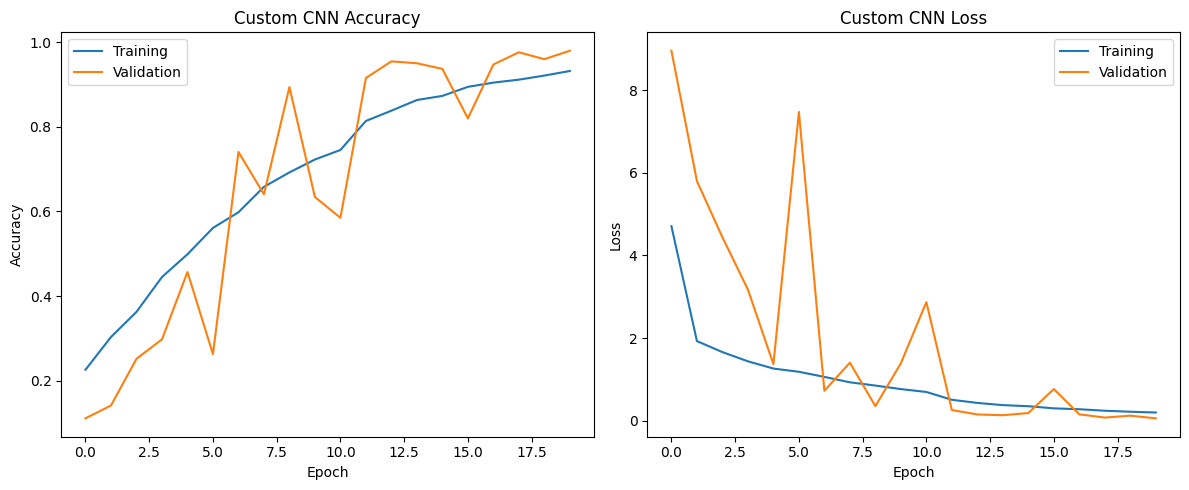

In [17]:
# ============================================================
# Learning Curves
# ============================================================

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_cnn.history['accuracy'], label='Training')
plt.plot(history_cnn.history['val_accuracy'], label='Validation')
plt.title('Custom CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history_cnn.history['loss'], label='Training')
plt.plot(history_cnn.history['val_loss'], label='Validation')
plt.title('Custom CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

43/43 ━━━━━━━━━━━━━━━━━━━━ 14s 319ms/step


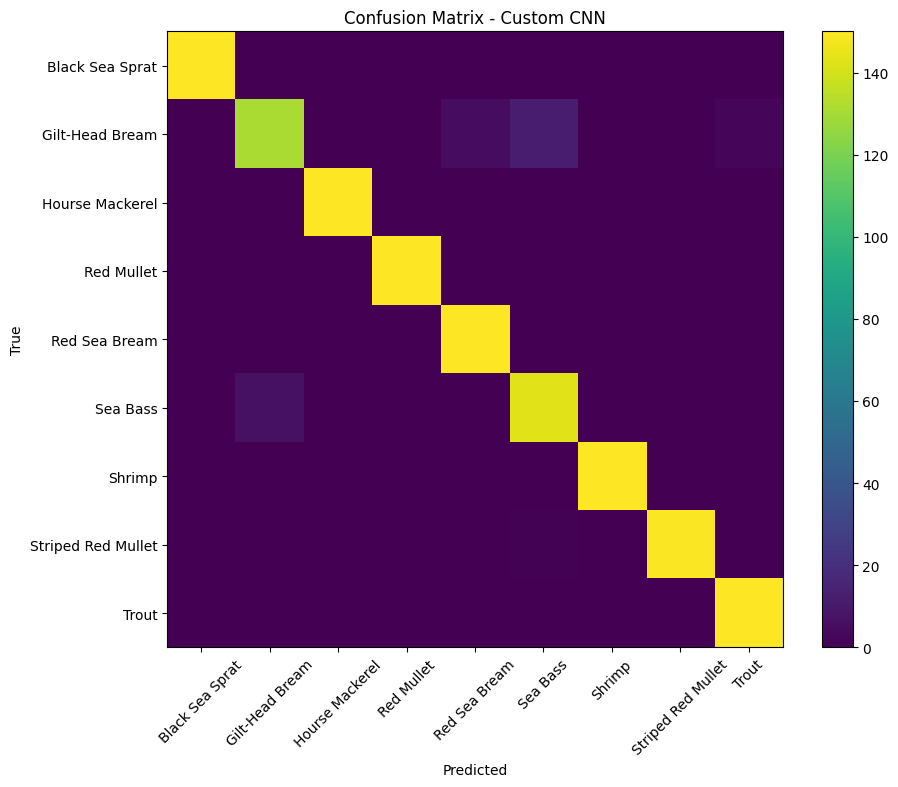

                    precision    recall  f1-score   support

   Black Sea Sprat       1.00      1.00      1.00       150
   Gilt-Head Bream       0.95      0.87      0.91       150
   Hourse Mackerel       1.00      1.00      1.00       150
        Red Mullet       1.00      1.00      1.00       150
     Red Sea Bream       0.97      1.00      0.98       150
          Sea Bass       0.92      0.95      0.93       150
            Shrimp       1.00      1.00      1.00       150
Striped Red Mullet       1.00      0.99      1.00       150
             Trout       0.99      1.00      0.99       150

          accuracy                           0.98      1350
         macro avg       0.98      0.98      0.98      1350
      weighted avg       0.98      0.98      0.98      1350



In [18]:
# ============================================================
# Confusion Matrix & Classification Report
# ============================================================

predictions = best_custom_cnn.predict(test_data)

predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_data.classes

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10,8))
plt.imshow(cm, cmap='viridis')
plt.title("Confusion Matrix - Custom CNN")
plt.colorbar()

plt.xticks(range(len(fish_classes)), fish_classes, rotation=45)
plt.yticks(range(len(fish_classes)), fish_classes)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=fish_classes
))

# MobileNetV2 Transfer Learning

In [19]:
from tensorflow.keras.applications import MobileNetV2

print("MobileNetV2 Imported Successfully!")

MobileNetV2 Imported Successfully!


In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

mobilenet_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(9, activation="softmax")
])

print("MobileNetV2 Model Created Successfully!")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 Model Created Successfully!


In [21]:
from tensorflow.keras.optimizers import Adam

mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("MobileNetV2 Compiled Successfully!")

MobileNetV2 Compiled Successfully!


In [22]:
mobilenet_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,233 (9.87 MB)

 Trainable params: 330,249 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [23]:
from tensorflow.keras.callbacks import ModelCheckpoint

mobilenet_checkpoint = ModelCheckpoint(
    "best_mobilenet.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

In [24]:
history_mobile = mobilenet_model.fit(

    train_data,

    validation_data=validation_data,

    epochs=10,

    callbacks=[
        early_stop,
        reduce_lr,
        mobilenet_checkpoint
    ]
)

print("Training Finished!")

Epoch 1/10


2026-07-03 19:35:05.558930: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-03 19:35:05.696388: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 11/197 ━━━━━━━━━━━━━━━━━━━━ 1:46 573ms/step - accuracy: 0.1224 - loss: 2.6341

2026-07-03 19:35:24.215771: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-03 19:35:24.353226: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 674ms/step - accuracy: 0.4052 - loss: 1.7276

2026-07-03 19:37:49.849874: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-03 19:37:49.987688: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_accuracy improved from None to 0.93852, saving model to best_mobilenet.keras

Epoch 1: finished saving model to best_mobilenet.keras
197/197 ━━━━━━━━━━━━━━━━━━━━ 183s 838ms/step - accuracy: 0.6087 - loss: 1.1856 - val_accuracy: 0.9385 - val_loss: 0.3677 - learning_rate: 1.0000e-04
Epoch 2/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 663ms/step - accuracy: 0.8655 - loss: 0.4651
Epoch 2: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.

Epoch 2: val_accuracy improved from 0.93852 to 0.96815, saving model to best_mobilenet.keras

Epoch 2: finished saving model to best_mobilenet.keras
197/197 ━━━━━━━━━━━━━━━━━━━━ 145s 737ms/step - accuracy: 0.8749 - loss: 0.4154 - val_accuracy: 0.9681 - val_loss: 0.1769 - learning_rate: 1.0000e-04
Epoch 3/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 652ms/step - accuracy: 0.9149 - loss: 0.2986
Epoch 3: val_accuracy improved from 0.96815 to 0.97333, saving model to best_mobilenet.keras

Epoch 3: finished saving model to best_mobilenet.keras
197

In [25]:
from tensorflow.keras.models import load_model

best_mobilenet = load_model("best_mobilenet.keras")

print("Best MobileNetV2 Loaded Successfully!")

Best MobileNetV2 Loaded Successfully!


In [26]:
test_loss_mobile, test_accuracy_mobile = best_mobilenet.evaluate(test_data)

print(f"\nMobileNetV2 Test Accuracy : {test_accuracy_mobile:.4f}")
print(f"MobileNetV2 Test Loss     : {test_loss_mobile:.4f}")

43/43 ━━━━━━━━━━━━━━━━━━━━ 28s 494ms/step - accuracy: 0.9696 - loss: 0.1445

MobileNetV2 Test Accuracy : 0.9696
MobileNetV2 Test Loss     : 0.1445


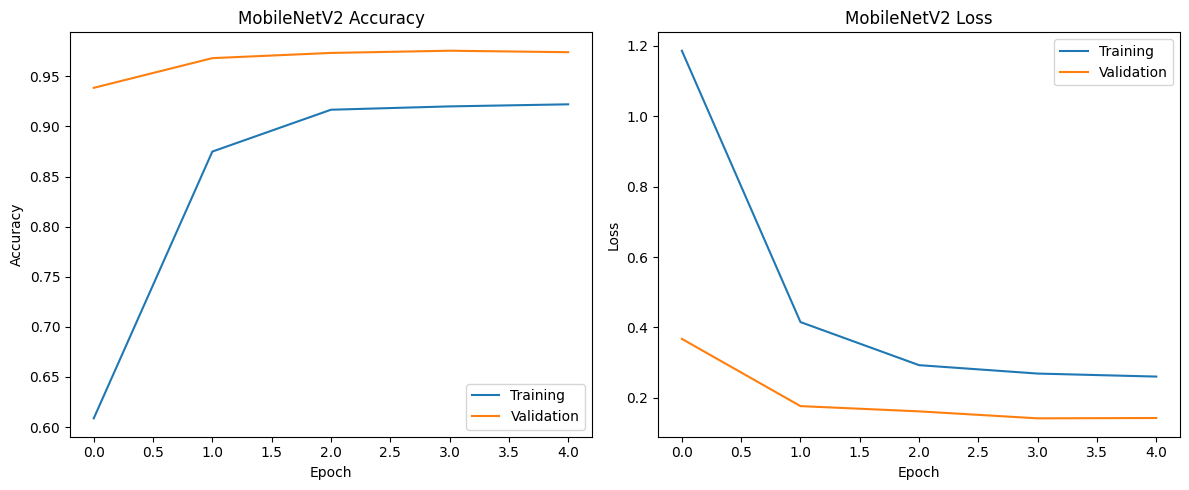

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_mobile.history['accuracy'], label='Training')
plt.plot(history_mobile.history['val_accuracy'], label='Validation')
plt.title("MobileNetV2 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_mobile.history['loss'], label='Training')
plt.plot(history_mobile.history['val_loss'], label='Validation')
plt.title("MobileNetV2 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

43/43 ━━━━━━━━━━━━━━━━━━━━ 27s 485ms/step


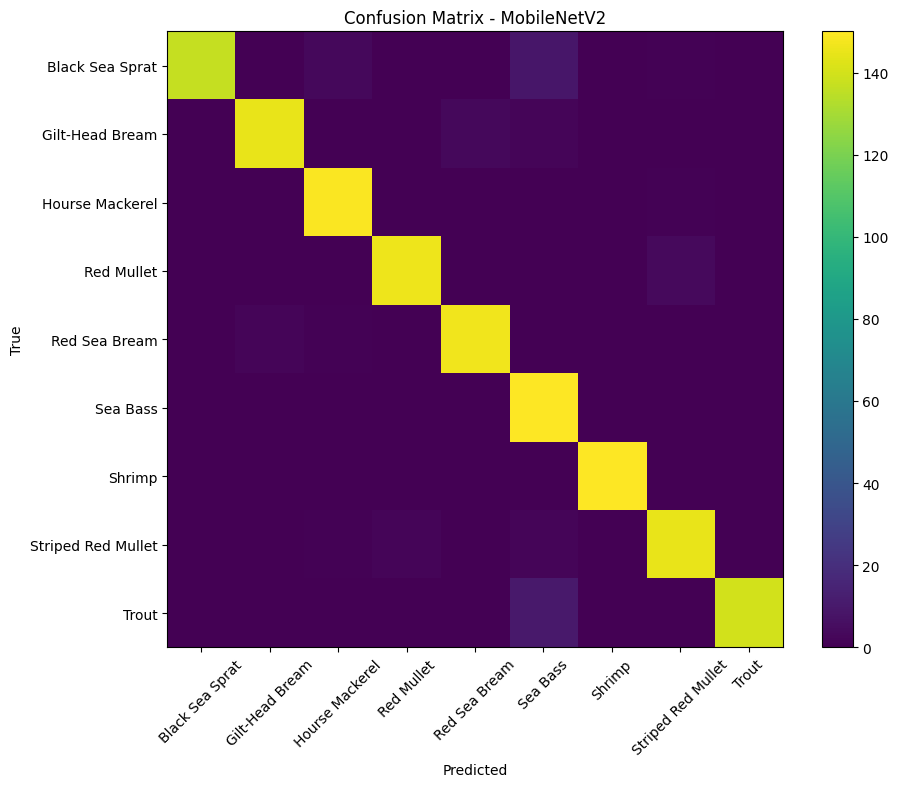

                    precision    recall  f1-score   support

   Black Sea Sprat       1.00      0.91      0.95       150
   Gilt-Head Bream       0.99      0.97      0.98       150
   Hourse Mackerel       0.97      0.99      0.98       150
        Red Mullet       0.99      0.97      0.98       150
     Red Sea Bream       0.98      0.98      0.98       150
          Sea Bass       0.87      1.00      0.93       150
            Shrimp       1.00      1.00      1.00       150
Striped Red Mullet       0.96      0.97      0.96       150
             Trout       1.00      0.93      0.97       150

          accuracy                           0.97      1350
         macro avg       0.97      0.97      0.97      1350
      weighted avg       0.97      0.97      0.97      1350



In [28]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

predictions = best_mobilenet.predict(test_data)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_data.classes

class_labels = list(test_data.class_indices.keys())

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10,8))
plt.imshow(cm, cmap='viridis')
plt.title("Confusion Matrix - MobileNetV2")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(np.arange(len(class_labels)), class_labels, rotation=45)
plt.yticks(np.arange(len(class_labels)), class_labels)
plt.colorbar()
plt.show()

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
))

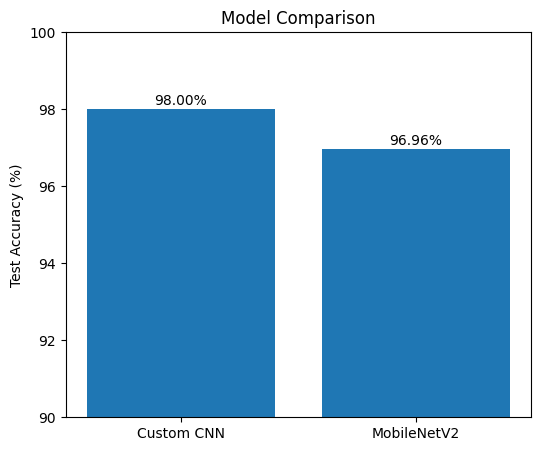

In [29]:
models = ['Custom CNN','MobileNetV2']

accuracies = [
    test_accuracy*100,
    test_accuracy_mobile*100
]

plt.figure(figsize=(6,5))

bars = plt.bar(models, accuracies)

plt.ylabel("Test Accuracy (%)")
plt.title("Model Comparison")
plt.ylim(90,100)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.1,
        f"{bar.get_height():.2f}%",
        ha='center'
    )

plt.show()

# Conclusion

This project developed a deep learning-based fish species classification system using the Large Scale Fish Dataset.

Two models were implemented and compared:

- Custom CNN
- MobileNetV2 (Transfer Learning)

The MobileNetV2 model achieved the highest classification performance, demonstrating the effectiveness of transfer learning for image classification tasks.

The developed system can support automated fish species identification in aquaculture, fisheries management, marine biodiversity monitoring, and seafood quality control.